# **DATA608 Assignment 1**
## **Prompt**

The attached [Excel file](https://raw.githubusercontent.com/Stevee-G/Data608/refs/heads/main/Assignment1/IIJA%20FUNDING%20AS%20OF%20MARCH%202023.csv) contains data on the present allocation of the Infrastructure Investment and Jobs Act funding by State and Territory.

Your story (Data Visualization(s)) should address the following questions:

Is the allocation equitable based on the population of each of the States and Territories, or is bias apparent?

Does the allocation favor the political interests of the Biden administration?

## **Python Packages**

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

## **Data Import**

In [74]:
url = "https://raw.githubusercontent.com/Stevee-G/Data608/refs/heads/main/Assignment1/IIJA%20FUNDING%20AS%20OF%20MARCH%202023.csv"
url1 = "https://raw.githubusercontent.com/Stevee-G/Data608/refs/heads/main/Assignment1/NST-EST2021-alldata.csv"
url2 = "https://raw.githubusercontent.com/Stevee-G/Data608/refs/heads/main/Assignment1/federalelections2020.csv"
url3 = "https://raw.githubusercontent.com/aruljohn/us-states/refs/heads/master/states.csv"

iija = pd.read_csv(url)
pop = pd.read_csv(url1)
elect = pd.read_csv(url2)
states = pd.read_csv(url3)

print("\nIIJA Funding:\n", iija.head(), "\n")
print("\nState and Territory Population:\n", pop.head())
print("\nState and Territory Election Results:\n", elect.head())
print("\nStates, Territories, and Their Abbreviations:\n", states.head())


IIJA Funding:
   State, Teritory or Tribal Nation  Total (Billions)
0                          ALABAMA            3.0000
1                           ALASKA            3.7000
2                   AMERICAN SAMOA            0.0686
3                          ARIZONA            3.5000
4                         ARKANSAS            2.8000 


State and Territory Population:
    SUMLEV REGION DIVISION  STATE              NAME  ESTIMATESBASE2020  \
0      10      0        0      0     United States          331449281   
1      20      1        0      0  Northeast Region           57609148   
2      20      2        0      0    Midwest Region           68985454   
3      20      3        0      0      South Region          126266107   
4      20      4        0      0       West Region           78588572   

   POPESTIMATE2020  POPESTIMATE2021  NPOPCHG_2020  NPOPCHG_2021  ...  \
0        331501080        331893745         51799        392665  ...   
1         57525633         57159838        -835

## **Data Wrangling**

In [75]:
iija['State, Teritory or Tribal Nation'] = iija['State, Teritory or Tribal Nation'].str.replace('DELEWARE','DELAWARE')

pop_trim = pop[['NAME','POPESTIMATE2020']]
pop_trim['NAME'] = pop_trim['NAME'].str.upper()

iija_pop = iija.merge(pop_trim,left_on='State, Teritory or Tribal Nation',
                               right_on='NAME',how='inner')

print(iija_pop.head())
print(iija_pop.tail())

  State, Teritory or Tribal Nation  Total (Billions)        NAME  \
0                          ALABAMA               3.0     ALABAMA   
1                           ALASKA               3.7      ALASKA   
2                          ARIZONA               3.5     ARIZONA   
3                         ARKANSAS               2.8    ARKANSAS   
4                       CALIFORNIA              18.4  CALIFORNIA   

   POPESTIMATE2020  
0          5024803  
1           732441  
2          7177986  
3          3012232  
4         39499738  
   State, Teritory or Tribal Nation  Total (Billions)           NAME  \
47                         VIRGINIA               4.5       VIRGINIA   
48                       WASHINGTON               4.0     WASHINGTON   
49                    WEST VIRGINIA               2.0  WEST VIRGINIA   
50                        WISCONSIN               2.8      WISCONSIN   
51                          WYOMING               2.3        WYOMING   

    POPESTIMATE2020  
47        

/tmp/ipykernel_11161/3137163463.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_trim['NAME'] = pop_trim['NAME'].str.upper()


In [76]:
elect_trim = elect.iloc[:,[0,1,2]].dropna(thresh=2)
elect_trim.columns = elect_trim.iloc[1]
elect_trim.iloc[:,0] = elect_trim.iloc[:,0].str.replace("*", "", regex=False)

states_trim = states[['ABBREVIATION',' NAME']]
states_trim[' NAME'] = states_trim[' NAME'].str.replace(r"[\"']","",regex=True)
states_trim[' NAME'] = states_trim[' NAME'].str.strip()

state_elect = states_trim.merge(elect_trim,left_on='ABBREVIATION',
                               right_on=elect_trim.iloc[:,0],how="left")
state_elect['Biden (D)'] = state_elect['Biden (D)'].fillna(0)
state_elect['Trunp (R)'] = state_elect['Trunp (R)'].fillna(0)
state_elect['Party'] = np.where(state_elect['Biden (D)'].astype(int)>
                                state_elect['Trunp (R)'].astype(int),
                                'Democrat',
                                np.where(state_elect['Biden (D)'].astype(int)<
                                         state_elect['Trunp (R)'].astype(int),
                                'Republican','Neither'))

print(state_elect.head())
print(state_elect.tail())

  ABBREVIATION        NAME NaN Biden (D) Trunp (R)       Party
0           AL     Alabama  AL         0         9  Republican
1           AK      Alaska  AK         0         3  Republican
2           AZ     Arizona  AZ        11         0    Democrat
3           AR    Arkansas  AR         0         6  Republican
4           CA  California  CA        55         0    Democrat
   ABBREVIATION                      NAME  NaN Biden (D) Trunp (R)    Party
60           AA     Armed Forces Americas  NaN         0         0  Neither
61           AE       Armed Forces Canada  NaN         0         0  Neither
62           AE       Armed Forces Europe  NaN         0         0  Neither
63           AE  Armed Forces Middle East  NaN         0         0  Neither
64           AP      Armed Forces Pacific  NaN         0         0  Neither


/tmp/ipykernel_11161/3925773102.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trim[' NAME'] = states_trim[' NAME'].str.replace(r"[\"']","",regex=True)
/tmp/ipykernel_11161/3925773102.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  states_trim[' NAME'] = states_trim[' NAME'].str.strip()


In [77]:
state_elect[' NAME'] = state_elect[' NAME'].str.upper()

all = iija_pop[['State, Teritory or Tribal Nation',
               'Total (Billions)',
                'POPESTIMATE2020']].merge(
                    state_elect[[' NAME',
                                 'Party']],
                    left_on='State, Teritory or Tribal Nation',
                    right_on=' NAME').drop(columns=' NAME')
all['Per Capita'] = round((all['Total (Billions)']*1000000000)/all['POPESTIMATE2020'])

print(all.head())
print(all.tail())

  State, Teritory or Tribal Nation  Total (Billions)  POPESTIMATE2020  \
0                          ALABAMA               3.0          5024803   
1                           ALASKA               3.7           732441   
2                          ARIZONA               3.5          7177986   
3                         ARKANSAS               2.8          3012232   
4                       CALIFORNIA              18.4         39499738   

        Party  Per Capita  
0  Republican       597.0  
1  Republican      5052.0  
2    Democrat       488.0  
3  Republican       930.0  
4    Democrat       466.0  
   State, Teritory or Tribal Nation  Total (Billions)  POPESTIMATE2020  \
47                         VIRGINIA               4.5          8632044   
48                       WASHINGTON               4.0          7718785   
49                    WEST VIRGINIA               2.0          1789798   
50                        WISCONSIN               2.8          5892323   
51                     

## **Data Visualizations**

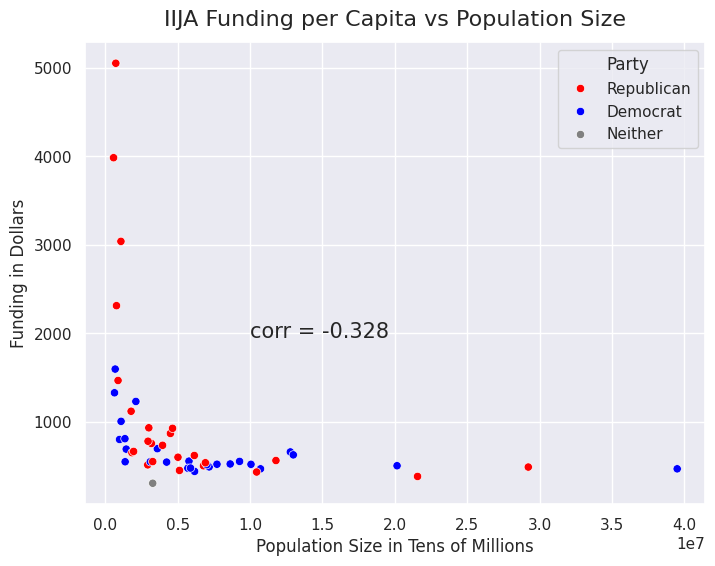

In [82]:
pal = {"Democrat":"blue",
       "Republican":"red",
       "Neither":"grey"}

fig, ax = plt.subplots()

sns.scatterplot(all,x='POPESTIMATE2020',y='Per Capita',
                hue='Party',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8, 6)})
ax.set_title('IIJA Funding per Capita vs Population Size',
             fontdict={'fontsize': 16},pad=12)
ax.set(xlabel='Population Size in Tens of Millions')
ax.set(ylabel='Funding in Dollars')

r = sp.stats.pearsonr(x=all['POPESTIMATE2020'],y=all['Per Capita'])[0]

plt.text(10000000,1950,'corr = '+str(round(r,3)),fontsize=15)

plt.show()

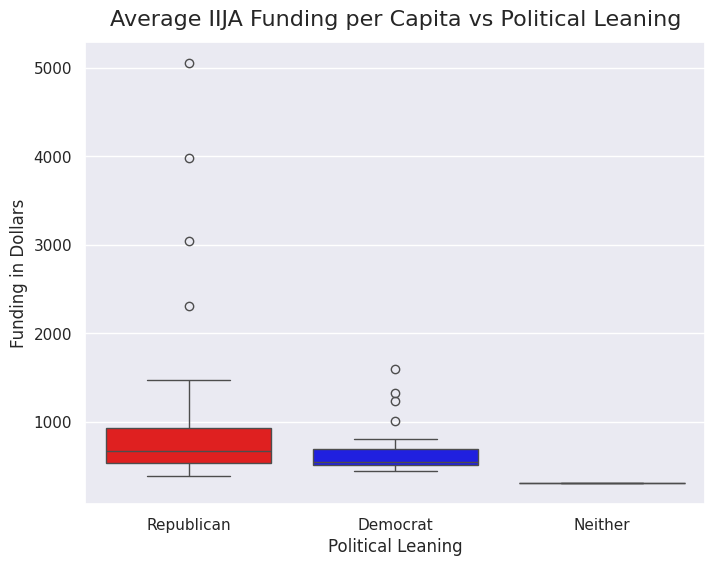

In [84]:
fig, ax = plt.subplots()

sns.boxplot(all,x='Party',y='Per Capita',hue='Party',
            palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8, 6)})
ax.set_title('Average IIJA Funding per Capita vs Political Leaning',
             fontdict={'fontsize': 16},pad=12)
ax.set(xlabel='Political Leaning')
ax.set(ylabel='Funding in Dollars')

plt.show()

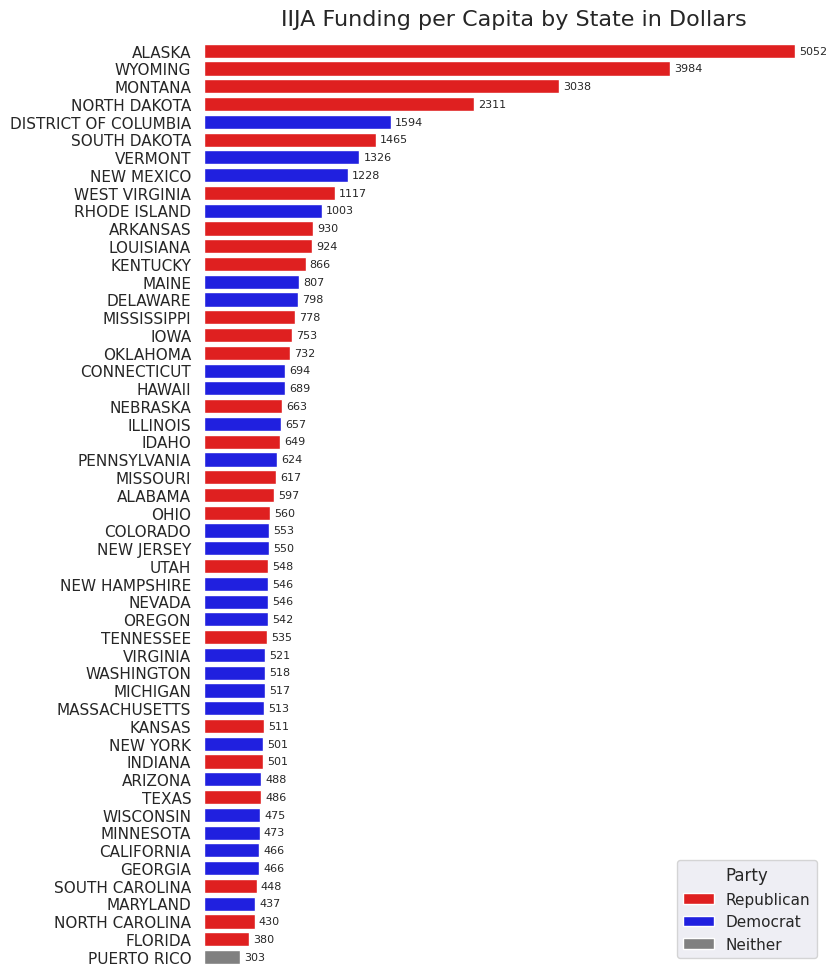

In [86]:
fig, ax = plt.subplots()

sns.barplot(all.sort_values(by='Per Capita',ascending=False),
            x='Per Capita',y='State, Teritory or Tribal Nation',
            hue='Party',palette=pal,ax=ax)
sns.set(rc={'figure.figsize':(8, 12)})
ax.set_facecolor('white')
ax.set_title('IIJA Funding per Capita by State in Dollars',
             fontdict={'fontsize': 16},pad=12)
ax.set(xlabel=None)
ax.set_xticklabels([])
ax.set(ylabel=None)

for c in ax.containers:
    ax.bar_label(c,fontsize=8,padding=3)

plt.show()

## **Sources**

2020 US Presidential Voting Results:

https://www.fec.gov/introduction-campaign-finance/election-results-and-voting-information/federal-elections-2020/

US State and Territory Population:

https://www2.census.gov/programs-surveys/popest/datasets/2020-2021/state/totals/

US State and Territory Names and Abbreviations:

https://aruljohn.com/usstates/